# Análisis exploratorio de la colección de proyectos

En este notebook, vamos a estudiar el corpus con la colección de proyectos que nos ha proporcionado la PAE. En este notebook analizamos el fichero **pae_aero_corpus.csv*, donde ademas de haber filtrado por keywords, también hicimos un filtrado quedándonos únicamente con los proyectos que guardaban una similitud semántica a un vector centro que se obtuvo a partir de las categorías de la taxonomía.


In [1]:
# Necesario montar nuestra unidad de google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd

os.chdir("/content/drive/MyDrive/PROYECTOS/PAE")
print("DIRECTORIO DE TRABAJO:", os.getcwd())
#os.listdir()

INPUT_FILE = "data/pae_aero_corpus.csv"
df = pd.read_csv(INPUT_FILE, encoding="utf-8")

print("Shape:", df.shape)
print("Columnas:", list(df.columns))

# borro la columna Nivel_1 que ya no nos aporta nada
if "Nivel_1" in list(df.columns):
    df.drop(columns=["Nivel_1"], inplace=True)
print("Columnas:", list(df.columns))

df.head()


DIRECTORIO DE TRABAJO: /content/drive/MyDrive/PROYECTOS/PAE
Shape: (733, 3)
Columnas: ['title', 'description', 'text']
Columnas: ['title', 'description', 'text']


,title,description,text
0,Tilt Rotor ATM Integrated Validation of Enviro...,"""Cleansky-Green Rotor Craft sub-project 5 is a...",Tilt Rotor ATM Integrated Validation of Enviro...
1,GNSS-based ATM for Rotorcraft to Decrease Emis...,The GARDEN project - GNSS-based ATM for Rotorc...,GNSS-based ATM for Rotorcraft to Decrease Emis...
2,Curved Applications for Rotorcraft Environment...,"""The CARE project – Curved Applications for Ro...",Curved Applications for Rotorcraft Environment...
3,Health Monitoring of Offshore Wind Farms,Offshore wind farm health monitoring and maint...,Health Monitoring of Offshore Wind Farms. Offs...
4,Helicopters Deploy GNSS in Europe,The objectives of this project are to demonstr...,Helicopters Deploy GNSS in Europe. The objecti...


El corpus tiene un tamaño de 733, que es suficiente para clasificación semántica.

## Longitud de los textos

In [5]:
for col in ["title", "description", "text"]:
    #df[f"{col}_n_chars"] = df[col].astype(str).str.len()
    df[f"{col}_n_words"] = df[col].astype(str).str.split().apply(len)

df[[c for c in df.columns if "n_words" in c]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
)

,title_n_words,description_n_words,text_n_words
count,733.000000,733.000000,733.000000
mean,8.881310,256.964529,265.845839
std,4.313639,57.483249,58.124297
min,1.000000,38.000000,40.000000
25%,6.000000,239.000000,247.000000
50%,8.000000,276.000000,284.000000
75%,11.000000,290.000000,299.000000
95%,17.000000,308.000000,319.400000
max,28.000000,601.000000,608.000000


## ¿Cómo son los títulos?

Los títulos son cortos y bastante homogéneos. 50% tienen entre 6 y 12 palabras. No hay dispersión extrema. Su longitud máxima es 28 palabras.

El title siempre va a concentrar mucha información de núcleo porque los títulos de un proyecto suelen nombrar el problema a resolver, suelen mencionar la tecnología clave, nombra el dominio de aplicación, y también suele incluir términos específicos.
Sin embargo, los títulos son demasiado cortos como para poder utilizarlos en una clasificación con una taxonomía tan compleja como la que estabamos trabajando.


## ¿Cómo son las descripciones de los proyectos??

Las descripciones de los proyectos son textos largos y relativamente homogéneos. Su IQR (25%–75%) es muy concentrado (239–290 proyectos).

También podemos ver que su desviación estándar (~57) es baja comparada con la media (264). Esto indica que estamos frente a una estructura muy estable de la descripción de los proyectos, que puede sugerir que probablemente hay un formato institucional estándar para su descripción, es decir, una posible plantilla.


## ¿Cómo son los textos completos (title + description)??
Como era de esperar, su media es 265 palabras, y su distribución es casi idéntica a la que hemos observado en el campo description (el título añade pocos términos).

Los textos son muy homogeneos, su IQR está muy concentrado entre 247 y 299 palabras. La desviación estándar es ≈ 58. Eso es relativamente bajo para textos técnicos largos.


El 95% de los proyectos tienen un tamaño de menos de 319 palabras.Es cierto que hay algunos outliers largos (más de 600 palabras). Estos pueden ser proyectos con descripción extendida, o textos concatenados accidentalmente, o problemas de limpieza. De todas formas, son muy pocos.

Por tanto, los proyectos tienen longitud muy consistente. Esto es excelente para embeddings.
* No habrá sesgo fuerte por longitud.
* No necesitas normalización especial.
* El modelo no se verá dominado por outliers.

## Implicaciones para clasificación automática


* Longitudes homogéneas → embeddings comparables
* No hay textos extremadamente cortos (min 40 palabras)
* Señal semántica suficiente en todos los casos
* Dataset limpio y coherente



In [7]:
# Prueba con distintos valores de X
X = 350
df_long_texts = df[df["text_n_words"] >= X].copy()
print(f"Número de texts con más de {X} palabras: {len(df_long_texts)}")

Número de texts con más de 350 palabras: 10


/tmp/ipython-input-1904552692.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


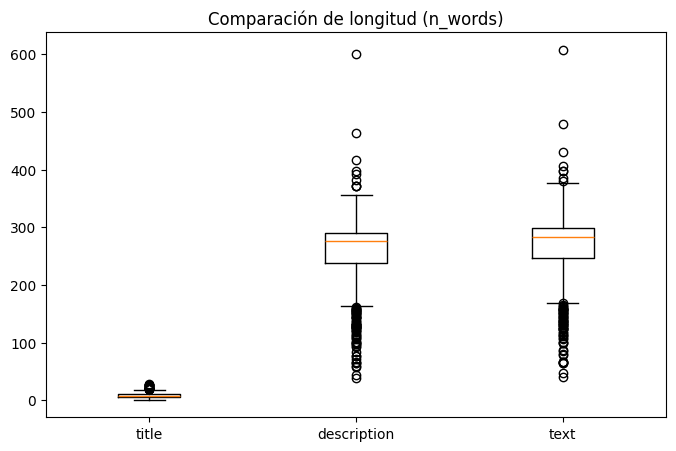

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(
    [df["title_n_words"], df["description_n_words"], df["text_n_words"]],
    labels=["title", "description", "text"]
)
plt.title("Comparación de longitud (n_words)")
plt.show()


Los títutlos (mediana ≈ 8 palabras) tienen un IQR estrecho (aprox. 6–11). Tienen algunos outliers hasta 25–30 palabras, que probablemente sean títulos muy descriptivos o con acrónimos extendidos.
* Alta homogeneidad
* Títulos compactos
* No hay inflación artificial
* Buena señal semántica: el título aporta información concentrada.


Las descripciones (Mediana ≈ 275–280 palabras) tienen un IQR relativamente estrecho (≈ 240–290). Algunos outliers largos (400–600).
Algunos textos cortos (~40–100 palabras). Esto indica:
* La mayoría de proyectos están muy concentrados en torno a 250–300 palabras. Seguramente sigan una plantilla estructural similar. Dominio técnico bien definido
* Los outliers largos (600 palabras) probablemente sean proyectos más detallados o con texto institucional extendido.
* Los outliers cortos pueden ser: Fichas incompletas o Resúmenes reducidos.

Como era de esperar, el campo text (title + description):
* Sigue la misma estructura que description
* Ligero desplazamiento hacia arriba (≈ +9 palabras del título)
* IQR muy compacto (~250–300)
* Excelente consistencia.

Este corpus es:

* Muy homogéneo en longitud
* Sin variabilidad extrema
* Sin textos excesivamente cortos
* Sin dispersión estructural fuerte

Eso es ideal para:

* Embeddings
* Clasificación semántica
* Similaridad proyecto–categoría


Sobre los outliersno son problemáticos. Representan casos extremos naturales. No afectan significativamente a embeddings (porque la mayoría están concentrados). Si fueran muchos textos de 10 palabras, sería un problema. Pero aquí el mínimo real relevante es ~40 palabras → suficiente señal semántica.


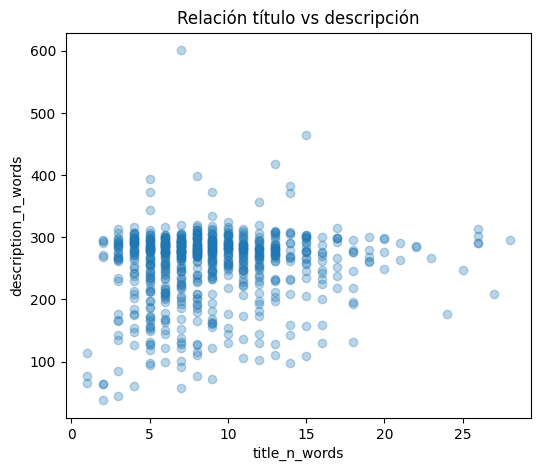

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(df["title_n_words"], df["description_n_words"], alpha=0.3)
plt.xlabel("title_n_words")
plt.ylabel("description_n_words")
plt.title("Relación título vs descripción")
plt.show()

**¿Hay correlación fuerte entre longitud del título y de la descripción?**

No existe correlación. Los puntos forman una nube bastante horizontal.
Para casi cualquier número de palabras en el título (3–15), la descripción suele estar entre 230–310 palabras. Por tanto, no hay correlación fuerte entre longitud del título y longitud de la descripción.

Eso es totalmente lógico porque el título es editorial, y la descripción parece seguir una plantilla más o menos fija.


La masa principal está en: title_n_words: 5–12, y description_n_words: 240–300. Esto confirma:

* Alta homogeneidad estructural
* Plantillas institucionales
* Corpus bien formado

📉 3️⃣ Outliers interesantes

Se observan algunos outliers, descripciones muy largas (~400–600), que aparecen tanto con títulos cortos como medios. Probablemente son proyectos con explicación técnica extensa
Los outliers con descripciones muy cortas (~50–150), también están distribuidas en varios tamaños de título. Posiblemente sean fichas resumidas o proyectos con información limitada.

Este gráfico sugiere algo importante que la señal semántica fuerte del documento está en la descripción, no en el título,  porque:

* La descripción es larga y relativamente constante.
* El título es compacto y no condiciona la longitud del cuerpo.

Para clasificación con embeddings:

* El campo text (title + description) es correcto.
* No necesitas ponderar especialmente por longitud.

📐 5️⃣ Implicación técnica para embeddings


Este scatter confirma que el corpus aeroespacial:

* Es estructuralmente homogéneo
* Tiene descripciones consistentes
* No presenta subgrupos evidentes por longitud
* Está listo para clasificación semántica

## Densidad lexica

Medimos el número de tokens únicos entre el número total de tokens.

Una densidad léxica cercana a 1.0 implica que en el texto casí no hay tokens repetidos.



In [10]:
import re
def lexical_density(text):
    words = re.findall(r"[A-Za-z]+", str(text).lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["title_lex_density"] = df["title"].apply(lexical_density)
df["desc_lex_density"] = df["description"].apply(lexical_density)

df[["title_lex_density", "desc_lex_density"]].describe()

,title_lex_density,desc_lex_density
count,733.000000,733.000000
mean,0.981431,0.573392
std,0.043449,0.053838
min,0.700000,0.431159
25%,1.000000,0.537705
50%,1.000000,0.571429
75%,1.000000,0.604167
max,1.000000,0.913043


El 75% de los títulos tienen densidad 1.0. Eso significa que no repiten palabras. Son muy compactos y altamente informativos. Cada palabra aparece una vez.
* Los títulos tienen altísima señal semántica.
* No hay redundancia interna.
* Son ideales para clasificación como señal auxiliar.

En el caso de las descripciones, la media ≈ 0.57 es muy coherente para textos técnicos largos. Significa que  el 43% son repetición (términos técnicos recurrentes, conectores, etc.).Su dispersión es baja, lo que indica:
* Corpus muy homogéneo.
* Nivel de repetición similar entre proyectos.
* No hay subconjuntos con estilos muy distintos.

Algunos textos tienen bastante repetición (mínimo 43%), posiblemente tenga boilerplate institucional, o se repitan muchos términos como: system, aircraft, engine, project, etc. Esto no es problemático.
De hecho, indica cohesión temática. Esto es típico en textos de ingeniería especializada.

El valor máximo (0.91) indica que los textos son muy técnicos, con mucha variedad terminológica y poca repetición. Son probablemente proyectos muy específicos.

El corpus es:

* Técnico
* Especializado
* Homogéneo
* Sin exceso de boilerplate


No necesitas:

* Quitar stopwords
* Hacer lematización agresiva
* Reducir texto
* La repetición técnica es informativa.

Los embeddings modernos manejan bien esta estructura.

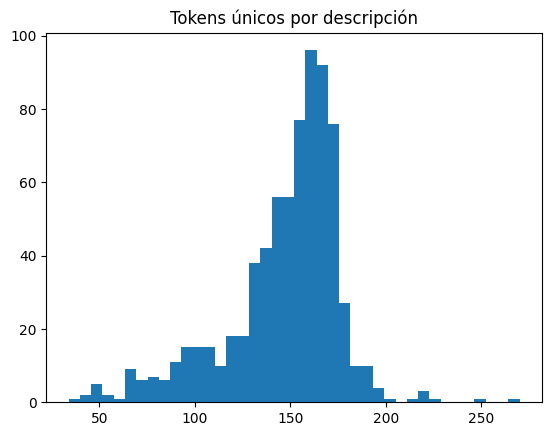

In [14]:
df["desc_unique_tokens"] = df["description"].apply(
    lambda x: len(set(re.findall(r"[A-Za-z]+", str(x).lower())))
)

plt.hist(df["desc_unique_tokens"], bins=40)
plt.title("Tokens únicos por descripción")
plt.show()

Se observa:

* Distribución claramente unimodal
* Pico principal alrededor de 150–170 tokens únicos
* Cola izquierda pequeña (~40–100)
* Cola derecha muy ligera (~200–260)

* No hay multimodalidad
* No hay subpoblaciones estructurales

* Eso confirma homogeneidad temática


Este corpus aeroespacial es:

✔ Técnicamente consistente
✔ Léxicamente homogéneo
✔ Sin extremos problemáticos
✔ Sin documentos ultra repetitivos

Eso es exactamente lo que quieres antes de clasificar.

### Inspección de outliers

Top 5 más largos

In [15]:
df.sort_values("description_n_words", ascending=False)[
    ["title", "description_n_words"]
].head(5)

,title,description_n_words
630,Open ScienCe Aeronautic & Air Transport Research,601
653,Unmanned Aerial Vehicle for protecting soft/cr...,464
691,Climate effects reduced by Innovative Concept ...,417
379,AS-DISCO - Audio Suite for Disruptive Cockpit ...,398
162,Kernel-based ARchitecture for safetY-critical ...,393


In [16]:
df.sort_values("description_n_words")[["title", "description_n_words"]].head(5)


,title,description_n_words
579,Systems ITD,38
564,Large Passenger Aircraft,44
322,HUMAN AIRCRAFT ROADMAP FOR VIRTUAL INTELLIGENT...,58
56,Landing Gear Noise Attenuation,60
565,AIRFRAME ITD,64


## Conclusión:

Tu corpus no parece:

- Ruido.
- Mezcla de dominios distintos.
- Extremadamente diverso.
- Parece un corpus técnico homogéneo con variación temática interna.

Eso es ideal para clasificación con embeddings.